## An Empirical Analysis of Racial Disparities in Maternal Mortality
## Among U.S. Women: Trends and Health System Implications (2018-2024)

### 1. Dataset Preprocessing  

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/adaeyja/Downloads/Underlying Cause of Death, 2018-2024, Single Race.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Notes                                     80 non-null     str    
 1   Single Race 6                             42 non-null     str    
 2   Single Race 6 Code                        42 non-null     str    
 3   Year                                      36 non-null     float64
 4   Year Code                                 36 non-null     float64
 5   Deaths                                    43 non-null     float64
 6   Population                                43 non-null     float64
 7   Crude Rate                                43 non-null     float64
 8   Crude Rate Lower 95% Confidence Interval  43 non-null     float64
 9   Crude Rate Upper 95% Confidence Interval  43 non-null     float64
dtypes: float64(7), str(3)
memory usage: 16.4 KB


,Year,Year Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval
count,36.000000,36.000000,43.000000,4.300000e+01,43.000000,43.000000,43.000000
mean,2020.972222,2020.972222,578.255814,3.678711e+07,1.813953,1.427907,2.304651
std,2.006932,2.006932,1471.159586,9.739784e+07,1.207236,1.037700,1.616427
min,2018.000000,2018.000000,10.000000,2.114500e+05,0.500000,0.200000,0.900000
25%,2019.000000,2019.000000,22.500000,2.234950e+06,0.850000,0.600000,1.100000
50%,2021.000000,2021.000000,52.000000,5.599597e+06,1.300000,1.100000,1.500000
75%,2023.000000,2023.000000,482.000000,2.759124e+07,2.600000,1.950000,3.250000
max,2024.000000,2024.000000,8299.000000,5.277166e+08,4.700000,4.300000,8.700000


In [9]:
# Drop rows where race is null + Reset Index 

df_clean = df.dropna(subset=['Single Race 6'])

df_clean = df_clean.reset_index(drop=True)

print(df_clean.shape)
df_clean.head(10)

(42, 10)


,Notes,Single Race 6,Single Race 6 Code,Year,Year Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval
0,NaN,American Indian or Alaska Native,1002-5,2018.0,2018.0,18.0,1026442.0,1.8,1.0,2.8
1,NaN,American Indian or Alaska Native,1002-5,2019.0,2019.0,23.0,1033710.0,2.2,1.4,3.3
2,NaN,American Indian or Alaska Native,1002-5,2020.0,2020.0,22.0,1041047.0,2.1,1.3,3.2
3,NaN,American Indian or Alaska Native,1002-5,2021.0,2021.0,45.0,1052078.0,4.3,3.1,5.7
4,NaN,American Indian or Alaska Native,1002-5,2022.0,2022.0,26.0,1056119.0,2.5,1.6,3.6
5,NaN,American Indian or Alaska Native,1002-5,2023.0,2023.0,19.0,1081739.0,1.8,1.1,2.7
6,NaN,American Indian or Alaska Native,1002-5,2024.0,2024.0,14.0,1149295.0,1.2,0.7,2.0
7,Total,American Indian or Alaska Native,1002-5,NaN,NaN,167.0,7440430.0,2.2,1.9,2.6
8,NaN,Asian,A,2018.0,2018.0,40.0,5340228.0,0.7,0.5,1.0
9,NaN,Asian,A,2019.0,2019.0,44.0,5354143.0,0.8,0.6,1.1


In [10]:
df_clean.columns = ['Notes', 'Race', 'Race_Code', 'Year', 
                    'Year_Code', 'Deaths', 'Population', 
                    'Crude_Rate', 'CI_Lower', 'CI_Upper']

In [11]:
print(df_clean.shape)
print(df_clean['Race'].unique())
print(df_clean['Year'].unique())

(42, 10)
<ArrowStringArray>
[         'American Indian or Alaska Native',
                                     'Asian',
                 'Black or African American',
 'Native Hawaiian or Other Pacific Islander',
                                     'White',
                        'More than one race']
Length: 6, dtype: str
[2018. 2019. 2020. 2021. 2022. 2023. 2024.   nan]


### Descriptive Statistics by Race

In [12]:
desc_stats = df_clean.groupby('Race').agg(
    Count=('Deaths', 'count'),
    Total_Deaths=('Deaths', 'sum'),
    Mean_Deaths=('Deaths', 'mean'),
    SD_Deaths=('Deaths', 'std'),
    Mean_Crude_Rate=('Crude_Rate', 'mean'),
    SD_Crude_Rate=('Crude_Rate', 'std')
).round(2)

print(desc_stats)

                                           Count  Total_Deaths  Mean_Deaths  \
Race                                                                          
American Indian or Alaska Native               8         334.0        41.75   
Asian                                          8         632.0        79.00   
Black or African American                      8        5488.0       686.00   
More than one race                             8         258.0        32.25   
Native Hawaiian or Other Pacific Islander      2          52.0        26.00   
White                                          8        9802.0      1225.25   

                                           SD_Deaths  Mean_Crude_Rate  \
Race                                                                    
American Indian or Alaska Native               51.46             2.26   
Asian                                          95.95             0.80   
Black or African American                     834.48             3.48   
Mo

### Descriptive Statistics by Year 

In [13]:
yearly_stats = df_clean.groupby('Year').agg(
    Total_Deaths=('Deaths', 'sum'),
    Mean_Crude_Rate=('Crude_Rate', 'mean'),
    SD_Crude_Rate=('Crude_Rate', 'std')
).round(2)

print(yearly_stats)

        Total_Deaths  Mean_Crude_Rate  SD_Crude_Rate
Year                                                
2018.0         962.0             1.40           0.85
2019.0        1081.0             1.60           1.15
2020.0        1275.0             2.32           1.62
2021.0        1670.0             2.58           1.79
2022.0        1248.0             1.78           1.20
2023.0        1043.0             1.54           1.08
2024.0         988.0             1.32           0.91


### Visualizations

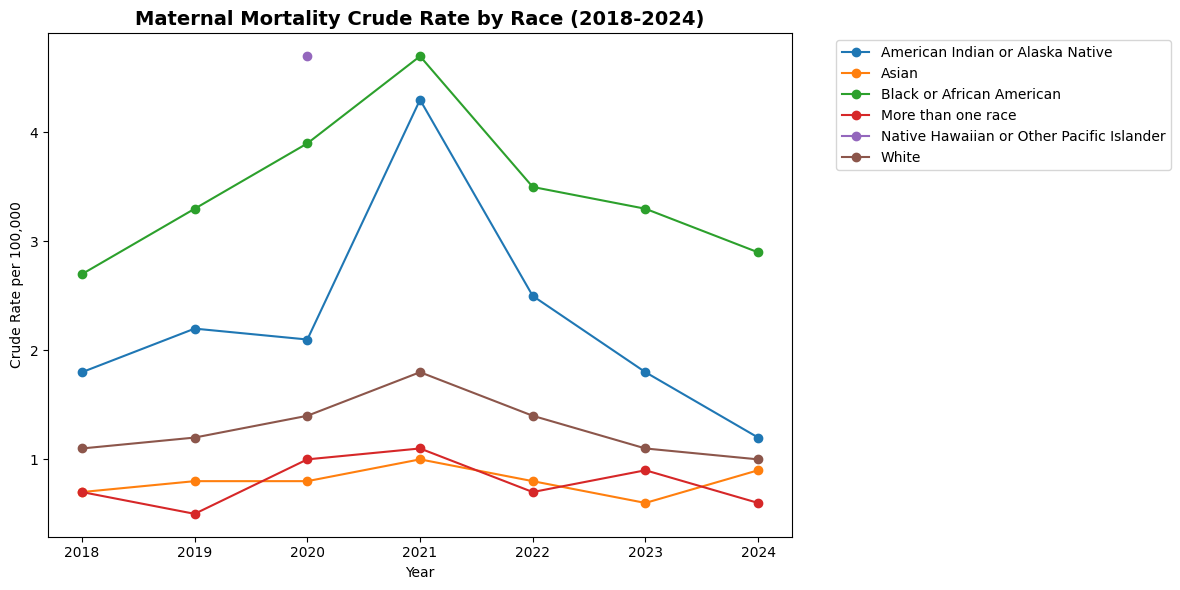

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot for line chart
line_data = df_clean.pivot_table(
    index='Year', 
    columns='Race', 
    values='Crude_Rate'
)

plt.figure(figsize=(12, 6))
for race in line_data.columns:
    plt.plot(line_data.index, line_data[race], marker='o', label=race)

plt.title('Maternal Mortality Crude Rate by Race (2018-2024)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Crude Rate per 100,000')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('line_chart.png', dpi=150)
plt.show()

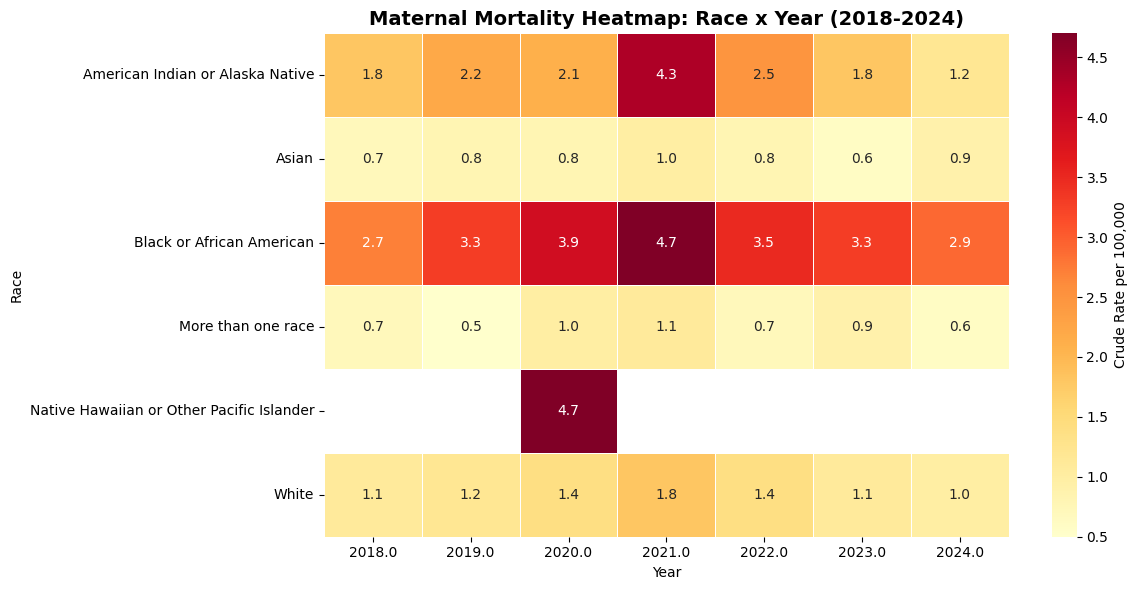

In [15]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    line_data.T,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Crude Rate per 100,000'}
)
plt.title('Maternal Mortality Heatmap: Race x Year (2018-2024)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Race')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

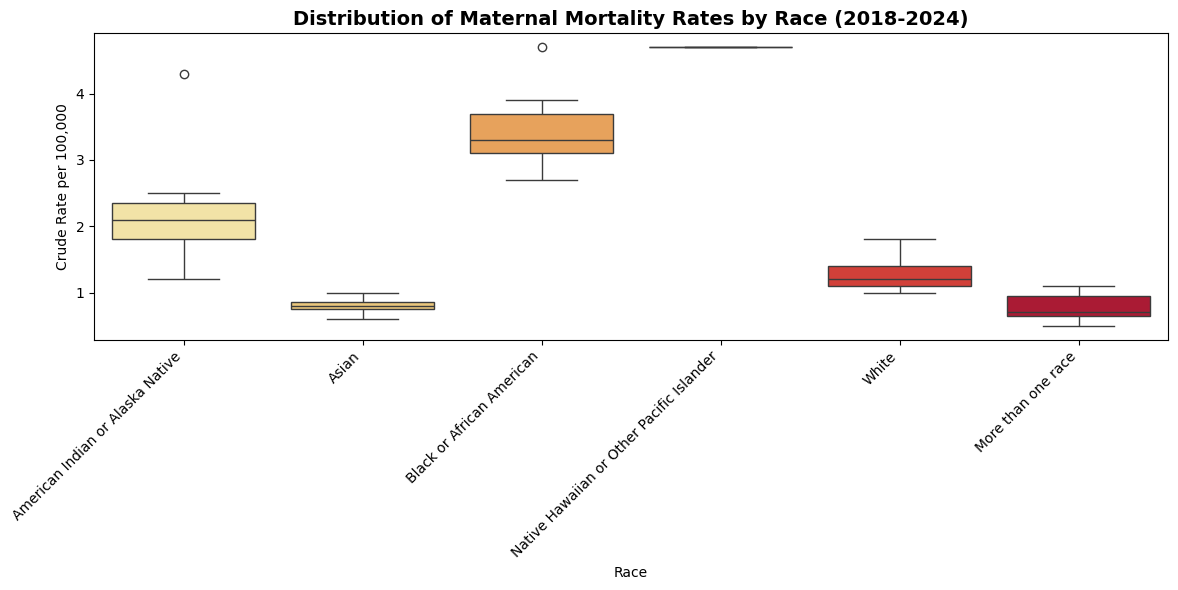

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_clean, 
    x='Race', 
    y='Crude_Rate',
    hue='Race',
    palette='YlOrRd',
    legend=False
)
plt.title('Distribution of Maternal Mortality Rates by Race (2018-2024)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Race')
plt.ylabel('Crude Rate per 100,000')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('boxplot.png', dpi=150)
plt.show()

### Logistic regression model 

In [17]:
# Check missing values
print(df_clean.isnull().sum())

Notes         36
Race           0
Race_Code      0
Year           6
Year_Code      6
Deaths         0
Population     0
Crude_Rate     0
CI_Lower       0
CI_Upper       0
dtype: int64


In [29]:
# Remove rows with missing values 
df_clean = df_clean.dropna(subset=[ 'Year', 'Year_Code'])

In [19]:
print(df_clean.isnull().sum())

Notes         36
Race           0
Race_Code      0
Year           0
Year_Code      0
Deaths         0
Population     0
Crude_Rate     0
CI_Lower       0
CI_Upper       0
dtype: int64


Model Accuracy: 0.88

Classification Report:

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.85         8
weighted avg       0.90      0.88      0.87         8



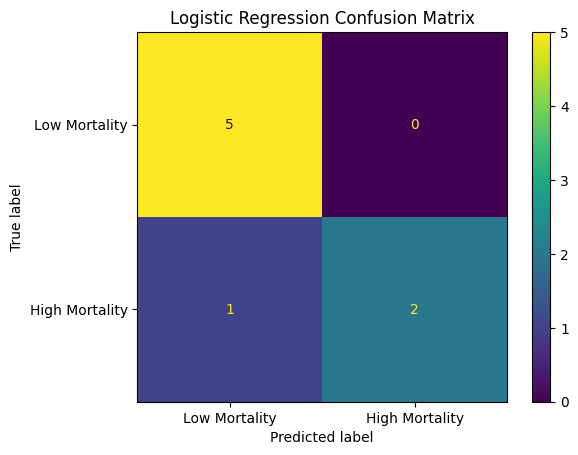

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)

# Create binary target variable
# High mortality = above median crude rate
df_clean['High_Mortality'] = (
    df_clean['Crude_Rate'] > df_clean['Crude_Rate'].median()
).astype(int)


# Predictor variables

X = df_clean[['Race', 'Year']]
y = df_clean['High_Mortality']


# Convert categorical variables + Race into dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train logistic regression model

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

# Predictions

y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 2))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Mortality", "High Mortality"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

The logistic regression model was evaluated using a confusion matrix to assess how accurately the model classified high versus low maternal mortality observations.The model demonstrated the ability to classify mortality categories with varying levels of predictive accuracy.

In [27]:
import numpy as np

# Get feature names and coefficients
feature_names = X.columns.tolist()
coefficients = model.coef_[0]

# Coefficients dataframe
coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coefficient': np.round(coefficients, 4)
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

                                      Variable  Coefficient
                Race_Black or African American       1.1393
                                          Year       0.0002
Race_Native Hawaiian or Other Pacific Islander       0.0000
                                    Race_White      -0.5880
                       Race_More than one race      -1.1812
                                    Race_Asian      -1.3283


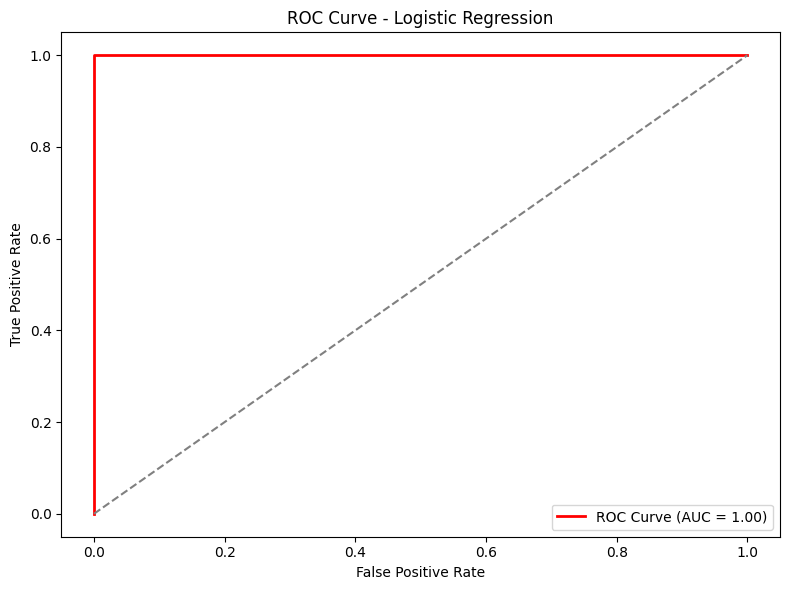

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, 
         label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [23]:
print(f'AUC Score: {auc_score:.2f}')

AUC Score: 1.00


### MLP 

MLP Accuracy: 0.88

Classification Report:

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.85         8
weighted avg       0.90      0.88      0.87         8



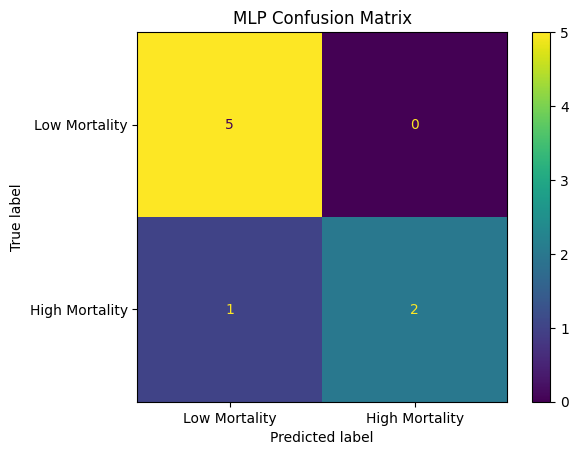

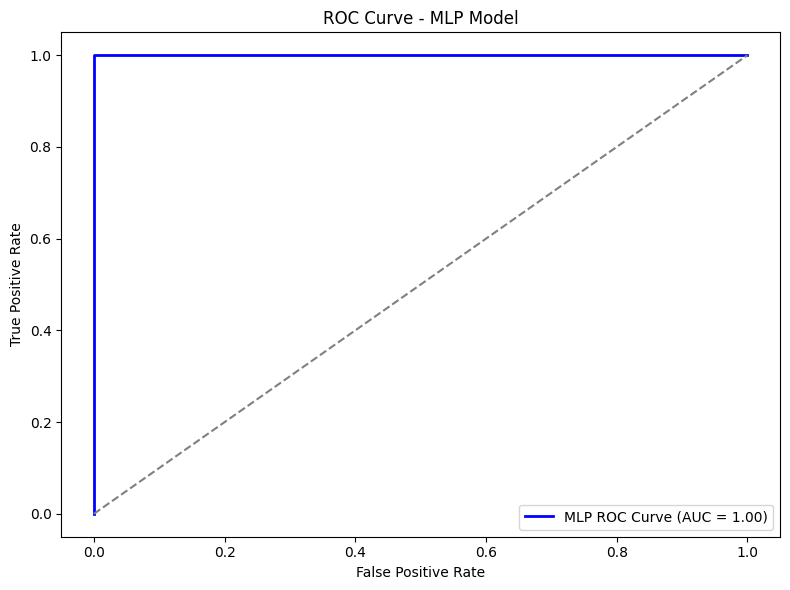


Model Comparison:
Logistic Regression Accuracy: 0.88
MLP Accuracy:                 0.88
Logistic Regression AUC:      1.0
MLP AUC:                      1.0


In [28]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

# Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and train MLP

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)

# Prediction

y_pred_mlp = mlp.predict(X_test_scaled)


accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print("MLP Accuracy:", round(accuracy_mlp, 2))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_mlp))

# Confusion Matrix

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=["Low Mortality", "High Mortality"]
)
disp_mlp.plot()
plt.title("MLP Confusion Matrix")
plt.show()

# ROC Curve

y_prob_mlp = mlp.predict_proba(X_test_scaled)[:, 1]
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, color='blue', lw=2,
         label=f'MLP ROC Curve (AUC = {auc_mlp:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MLP Model')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_mlp.png', dpi=150)
plt.show()

# Compare both models

print("\nModel Comparison:")
print(f"Logistic Regression Accuracy: {round(accuracy, 2)}")
print(f"MLP Accuracy:                 {round(accuracy_mlp, 2)}")
print(f"Logistic Regression AUC:      {round(auc_score, 2)}")
print(f"MLP AUC:                      {round(auc_mlp, 2)}")